In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget

In [3]:
data_ref = pd.read_csv('Averaged_01_ref.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

data_glass = pd.read_csv('Averaged_02_BS-12_glass.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

data_plastic = pd.read_csv('Averaged_03_plastic.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

data_linbo3 = pd.read_csv('Averaged_04_NbLiO3.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

time_ps = data_ref["time_ps"].to_numpy()
signal_ref = data_ref["signal"].to_numpy()
signal_glass = data_glass["signal"].to_numpy()
signal_plastic = data_plastic["signal"].to_numpy()
signal_linbo3 = data_linbo3["signal"].to_numpy()

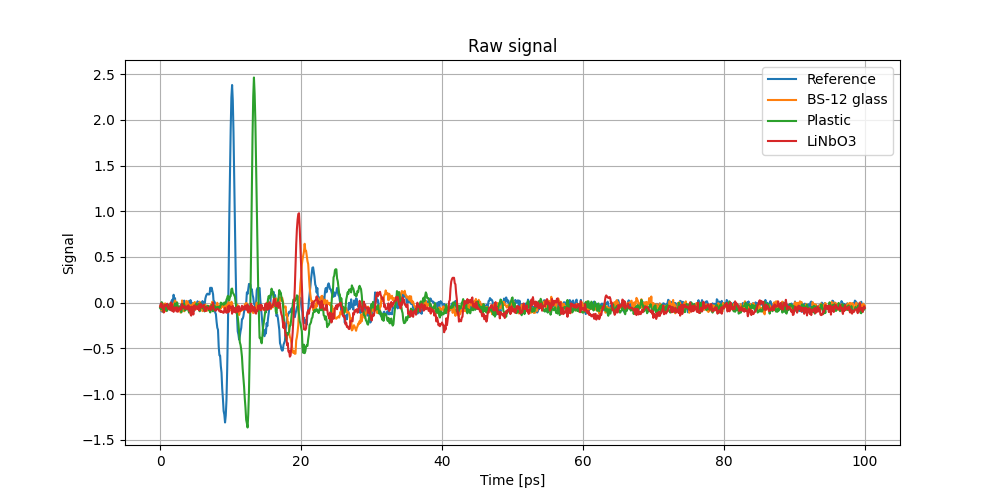

In [5]:
fig1 = plt.figure(figsize=(10,5))

ax1 = fig1.add_subplot(111)
ax1.set_title(r'Raw signal')
ax1.plot(time_ps, signal_ref, label="Reference")
ax1.plot(time_ps, signal_glass, label="BS-12 glass")
ax1.plot(time_ps, signal_plastic, label="Plastic")
ax1.plot(time_ps, signal_linbo3, label="LiNbO3")
ax1.set_xlabel('Time [ps]')
ax1.set_ylabel('Signal')
ax1.grid()
ax1.legend()

In [10]:
f_max_thz = 1/(2 * (time_ps[1] - time_ps[0]))

freqs_thz = np.linspace(-f_max_thz, f_max_thz, time_ps.shape[0])

spec_ref = np.fft.fftshift(np.fft.fft(signal_ref, norm='ortho'))
spec_glass = np.fft.fftshift(np.fft.fft(signal_glass, norm='ortho'))
spec_plastic = np.fft.fftshift(np.fft.fft(signal_plastic, norm='ortho'))
spec_linbo3 = np.fft.fftshift(np.fft.fft(signal_linbo3, norm='ortho'))

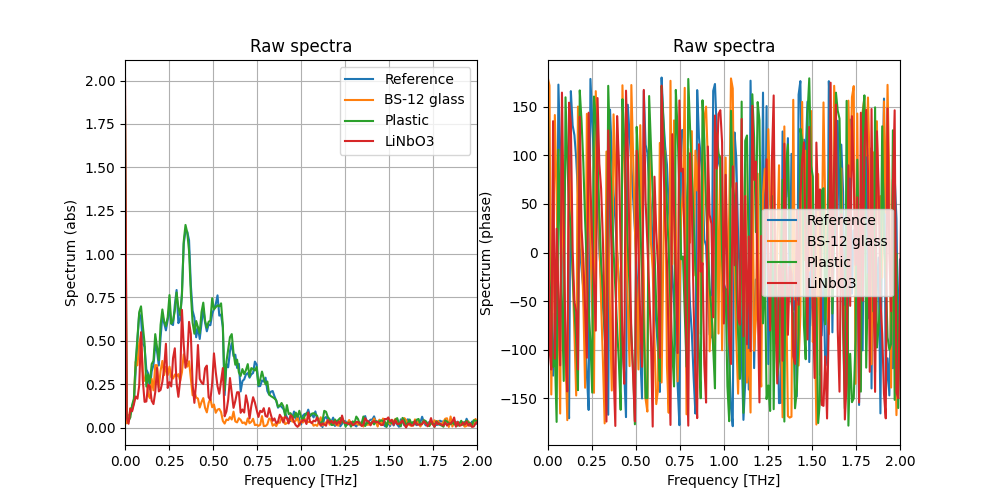

In [12]:
fig2 = plt.figure(figsize=(10,5))

ax1 = fig2.add_subplot(121)
ax1.set_title(r'Raw spectra')
ax1.plot(freqs_thz, np.abs(spec_ref), label="Reference")
ax1.plot(freqs_thz, np.abs(spec_glass), label="BS-12 glass")
ax1.plot(freqs_thz, np.abs(spec_plastic), label="Plastic")
ax1.plot(freqs_thz, np.abs(spec_linbo3), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (abs)')
ax1.set_xlim(left=0.0, right=2.0)
ax1.grid()
ax1.legend()

ax1 = fig2.add_subplot(122)
ax1.set_title(r'Raw spectra')
ax1.plot(freqs_thz, np.angle(spec_ref, deg=True), label="Reference")
ax1.plot(freqs_thz, np.angle(spec_glass, deg=True), label="BS-12 glass")
ax1.plot(freqs_thz, np.angle(spec_plastic, deg=True), label="Plastic")
ax1.plot(freqs_thz, np.angle(spec_linbo3, deg=True), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (phase)')
ax1.set_xlim(left=0.0, right=2.0)
ax1.grid()
ax1.legend()